#  TP1 

### 1)Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación-

In [52]:

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import supervision as sv



In [45]:
# Cargamos las 3 imagenes (Estan en BRG)
img_test_blue = cv.imread('archivos/TP1/white_patch/wp_blue.jpg')
img_test_red = cv.imread('archivos/TP1/white_patch/wp_red.png')
img_test_green = cv.imread('archivos/TP1/white_patch/wp_green.png')



Tamaños: (813, 481, 3) (571, 363, 3) (1600, 1200, 3)
Tipos: uint8 uint8 uint8


In [30]:
# Convertimos de BGR a RGB

imgRGB_test_blue = cv.cvtColor(img_test_blue, cv.COLOR_BGR2RGB)
imgRGB_test_green = cv.cvtColor(img_test_green, cv.COLOR_BGR2RGB)
imgRGB_test_red = cv.cvtColor(img_test_red, cv.COLOR_BGR2RGB)

In [53]:
# El algoritmo white patch, toma el valor maximo en el canal (R-G-B) y lo lleva al maximo que es 255
# Los demás valores de la matriz se multiplican por el factor de conversion que se aplicó para llevar hasta 255 el max.

max_test_blue = imgRGB_test_blue.max()
max_test_red = imgRGB_test_red.max()
max_test_green = imgRGB_test_green.max()

In [32]:
blue_fixed = imgRGB_test_blue * (255/max_test_blue)
red_fixed = imgRGB_test_red * (255/max_test_red)
green_fixed = imgRGB_test_green * (255/max_test_green)


In [33]:
# Al multiplicar valores de una matrix por coeficientes, nos da como resultado punto flotante, asi que tenemos
# convertir a unsigned int 8
blue_fixed = blue_fixed.astype('uint8')
red_fixed = red_fixed.astype('uint8')
green_fixed = green_fixed.astype('uint8')

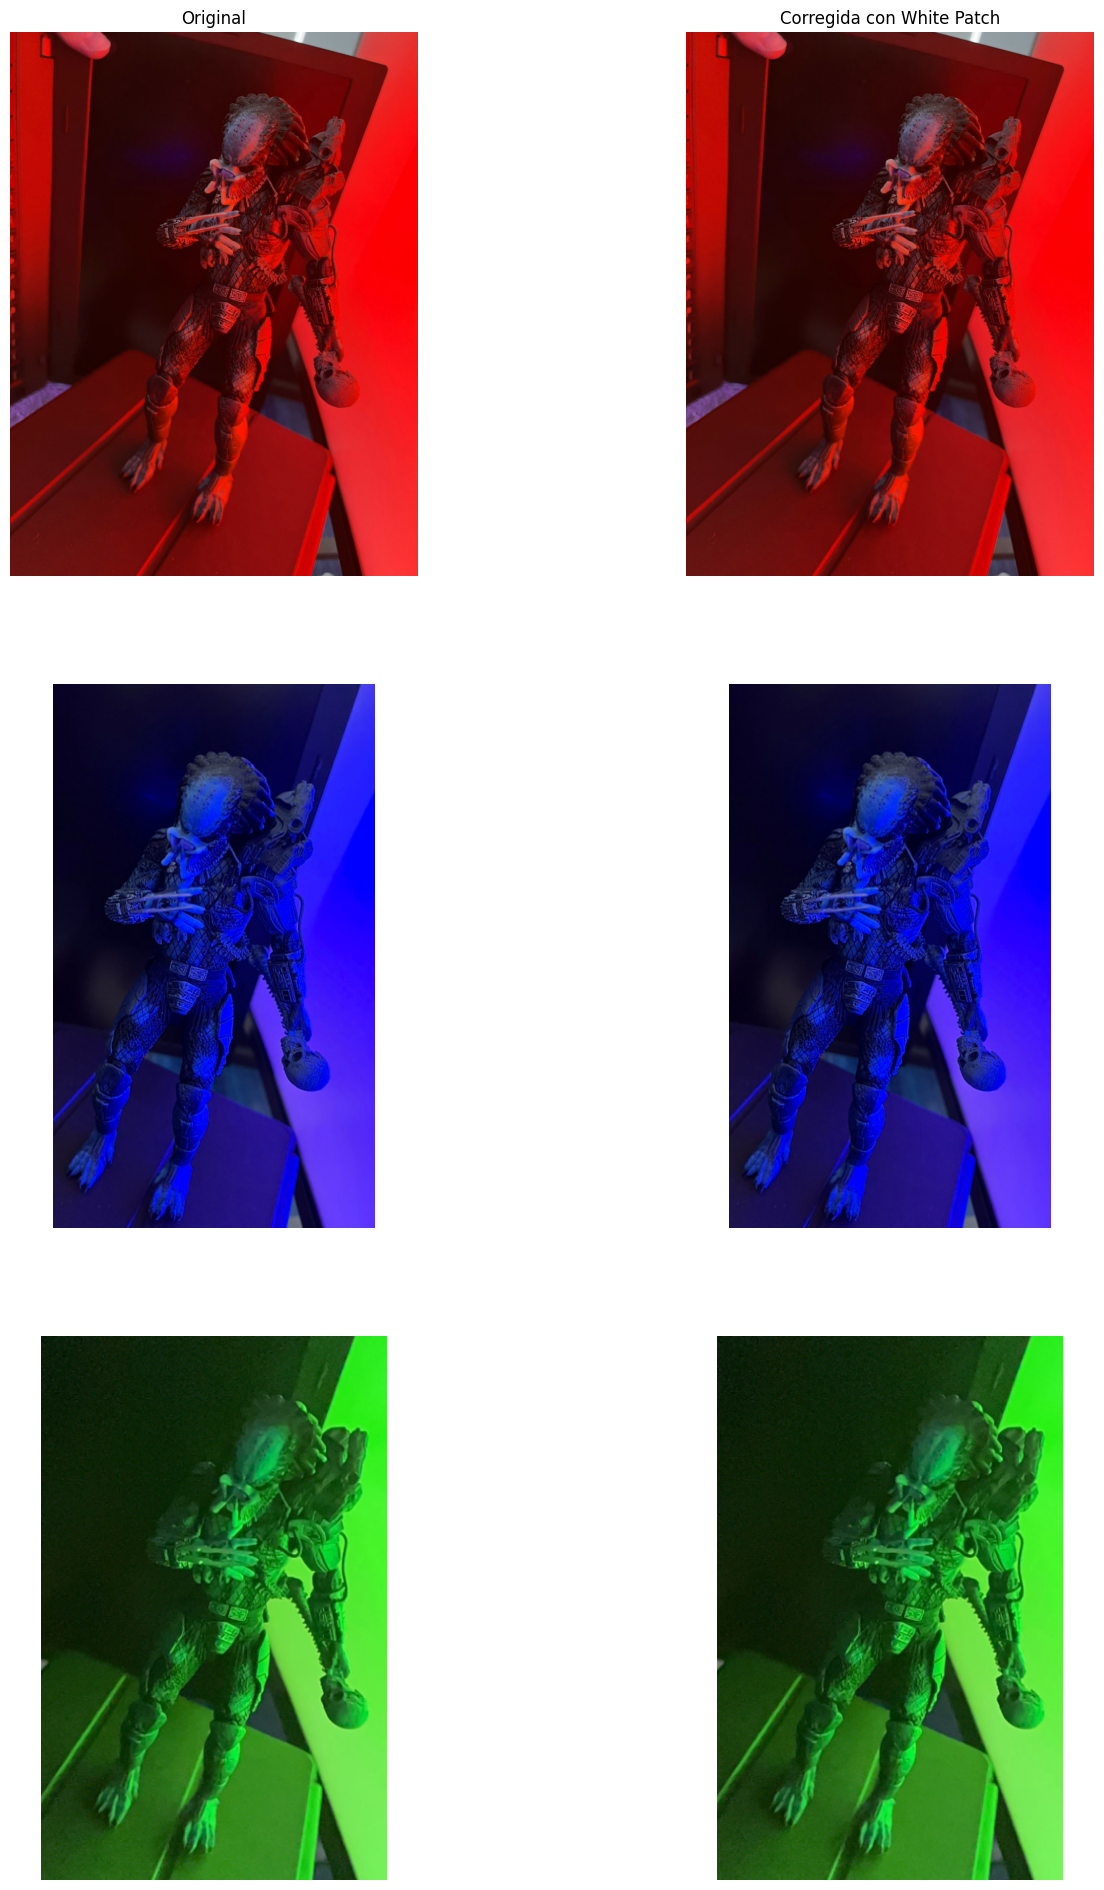

In [34]:
# Lista con las imágenes que quieres mostrar
imagenes = [imgRGB_test_blue, blue_fixed, imgRGB_test_red , red_fixed, imgRGB_test_green, green_fixed]

# Lista con los títulos para cada imagen
titulos = ["Original", "Corregida con White Patch"]

# Ploteo de la cuadrícula
sv.plot_images_grid(
    images=imagenes,
    grid_size=(3, 2),  # 1 fila, 2 columnas
    titles=titulos,
    size=(16, 24)
)

In [ ]:
# Misma operativa con las imagenes de manos.

In [48]:
img_hands_blue = cv.imread('archivos/TP1/white_patch/test_blue.png')
img_hands_red = cv.imread('archivos/TP1/white_patch/test_red.png')
img_hands_green = cv.imread('archivos/TP1/white_patch/test_green.png')

In [36]:
imgRGB_hands_blue = cv.cvtColor(img_hands_blue, cv.COLOR_BGR2RGB)
imgRGB_hands_red = cv.cvtColor(img_hands_red, cv.COLOR_BGR2RGB)
imgRGB_hands_green = cv.cvtColor(img_hands_green, cv.COLOR_BGR2RGB)

In [37]:
max_hands_blue = imgRGB_hands_blue.max()
max_hands_red = imgRGB_hands_red.max()
max_hands_green = imgRGB_hands_green.max()

In [42]:
blue_hands_fixed = imgRGB_hands_blue * (255/max_hands_blue)
red_hands_fixed = imgRGB_hands_red * (255/max_hands_red)
green_hands_fixed = imgRGB_hands_green * (255/max_hands_green)

In [43]:
blue_hands_fixed = blue_hands_fixed.astype('uint8')
red_hands_fixed = red_hands_fixed.astype('uint8')
green_hands_fixed = green_hands_fixed.astype('uint8')

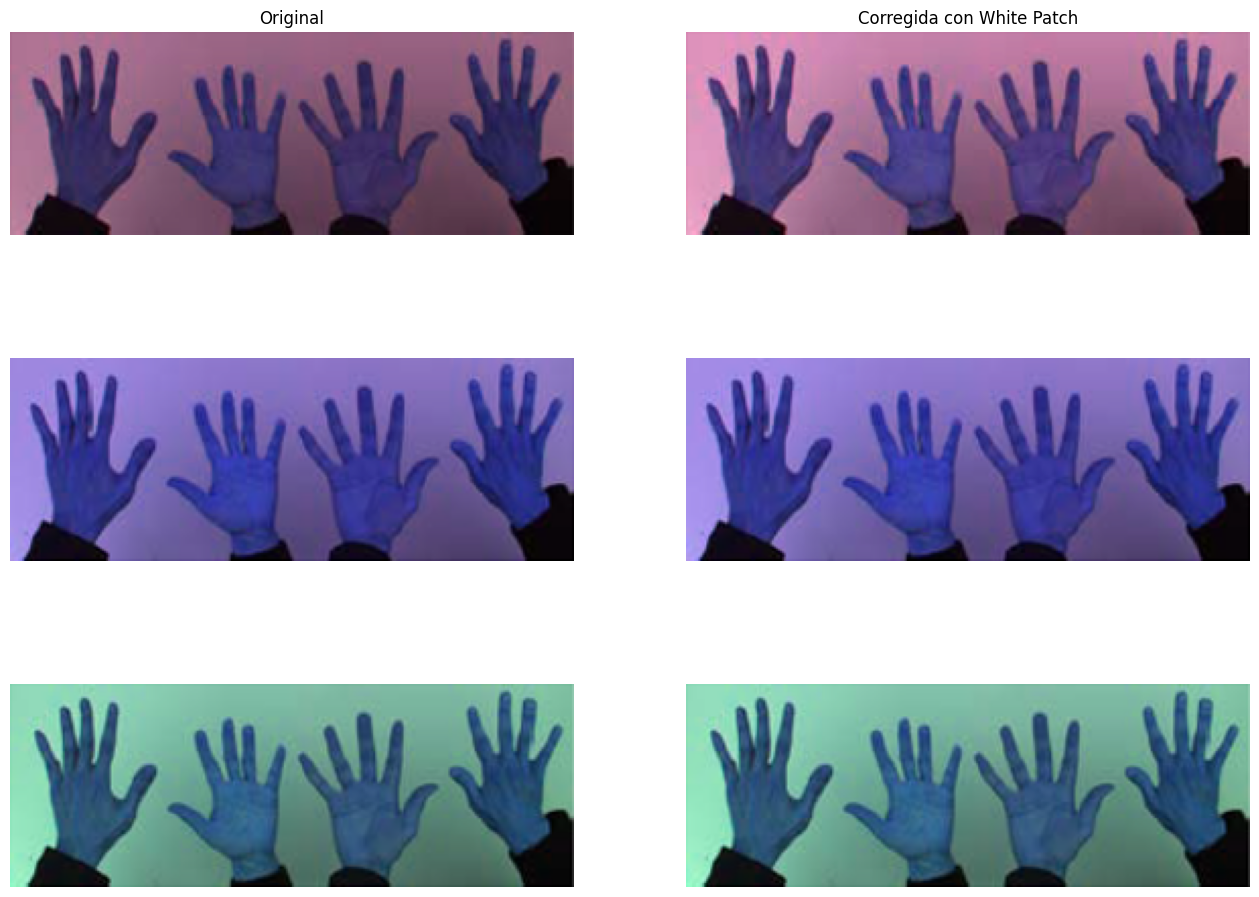

In [51]:
# Lista con las imágenes que quieres mostrar
imagenes2 = [imgRGB_hands_blue, blue_hands_fixed, imgRGB_hands_red , red_hands_fixed, imgRGB_hands_green, green_hands_fixed]

# Lista con los títulos para cada imagen
titulos = ["Original", "Corregida con White Patch"]

# Ploteo de la cuadrícula
sv.plot_images_grid(
    images=imagenes2,
    grid_size=(3, 2),  # 1 fila, 2 columnas
    titles=titulos,
    size=(16, 12)
)

In [67]:
#

Tamaños: (100, 278, 3) (99, 276, 3) (100, 278, 3)
Máximo del canal Rojo: 255
Máximo del canal Verde: 255


In [57]:
alto = blue_hands_fixed.shape[0]
ancho = blue_hands_fixed.shape[1]

In [60]:
red_hands_resized = cv.resize(red_hands_fixed, (ancho,alto))

In [62]:
imagen_mergeada = cv.merge([red_hands_resized,green_hands_fixed, blue_hands_fixed])

In [63]:
sv.plot_image(imagen_mergeada)

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.simd_helpers.hpp:92: error: (-15:Bad number of channels) in function 'cv::impl::{anonymous}::CvtHelper<VScn, VDcn, VDepth, sizePolicy>::CvtHelper(cv::InputArray, cv::OutputArray, int) [with VScn = cv::impl::{anonymous}::Set<3, 4>; VDcn = cv::impl::{anonymous}::Set<3, 4>; VDepth = cv::impl::{anonymous}::Set<0, 2, 5>; cv::impl::{anonymous}::SizePolicy sizePolicy = cv::impl::<unnamed>::NONE; cv::InputArray = const cv::_InputArray&; cv::OutputArray = const cv::_OutputArray&]'
> Invalid number of channels in input image:
>     'VScn::contains(scn)'
> where
>     'scn' is 9


<Figure size 1200x1200 with 0 Axes>